In [10]:
import pandas as pan
import matplotlib.pyplot as plt
import numpy as np

f0  = pan.read_csv("../data/experimental2/filtered/f0.csv")
f1  = pan.read_csv("../data/experimental2/filtered/f1.csv")

m0  = pan.read_csv("../data/experimental2/filtered/m0.csv")
m1  = pan.read_csv("../data/experimental2/filtered/m1.csv")
parts0 = pan.read_csv("../data/experimental2/filtered/participantswithf0.csv")
parts1 = pan.read_csv("../data/experimental2/filtered/participantswithf1.csv")

In [11]:
print(f0.groupby("action_name")["feedback"].value_counts(normalize=False))
print(f1.groupby("action_name")["feedback"].value_counts(normalize=False))

action_name  feedback         
as_usual     Oui                  60
             Non                   7
             Oui, mais pas sûr     6
monthly      Oui                  46
             Oui, mais pas sûr    18
             Non                   9
weekly       Oui, mais pas sûr    37
             Non                  22
             Oui                  14
Name: count, dtype: int64
action_name  feedback         
monthly      Oui                  62
             Oui, mais pas sûr     7
             Non                   2
notatall     Oui                  58
             Non                   7
             Oui, mais pas sûr     6
weekly       Oui                  49
             Oui, mais pas sûr    18
             Non                   4
Name: count, dtype: int64


In [12]:
parts0["gender "].groupby(parts0["gender "]).count()
#parts0["gender "].groupby(parts0["gender "]).count()


gender 
Feminin               35
Masculin              36
Ne se prononce pas     2
Name: gender , dtype: int64

In [13]:
feedback_map = {"Oui":1, "Oui, mais pas sûr":0.5,"Non":0}
def compute_meanfeedback(df):
    feedbacks_per_motivation = {-3:[],-2:[],-1:[],0:[],1:[],2:[],3:[]}

    def update_feedbacks(row):
        feedbacks_per_motivation[row["motivation"]].append(row["nfeedback"])

    df["nfeedback"] = df["feedback"].map(feedback_map)
    df.apply(update_feedbacks,axis=1)

    denulify = lambda  x: x+1*(x==0)
    meanfeedback_per_motivation = {k:sum(v)/(denulify(len(v))) for (k,v) in feedbacks_per_motivation.items()}
    feedbackerr_per_motvation = {k:np.std(v)/(np.sqrt(len(v)))for (k,v) in feedbacks_per_motivation.items()}
    x,y = [],[]
    for (k,v) in feedbacks_per_motivation.items():
        for j in v:
            x.append(k)
            y.append(j)
    model = np.polyfit(x,y,deg = 2)
    return feedbacks_per_motivation,meanfeedback_per_motivation,feedbackerr_per_motvation,model

def compute_meanfeedback_per_action(df):
    feedbacks_per_motivation_per_action = {"weekly":{-3:[],-2:[],-1:[],0:[],1:[],2:[],3:[]},"monthly":{-3:[],-2:[],-1:[],0:[],1:[],2:[],3:[]},"as_usual":{-3:[],-2:[],-1:[],0:[],1:[],2:[],3:[]}}

    def update_feedbacks(row):
        if row["nfeedback"] != 0.8:
            feedbacks_per_motivation_per_action[row["action_name"]][row["motivation"]].append(row["nfeedback"])
    
    

    df["nfeedback"] = df["feedback"].map(feedback_map)
    df.apply(update_feedbacks,axis=1)
    res = {}
    for ac in ["weekly","monthly","as_usual"]:
        feedbacks_per_motivation = feedbacks_per_motivation_per_action[ac]
        denulify = lambda  x: x+1*(x==0)
        meanfeedback_per_motivation = {k:sum(v)/(denulify(len(v))) for (k,v) in feedbacks_per_motivation.items()}
        feedbackerr_per_motvation = {k:np.std(v)/(np.sqrt(len(v)))for (k,v) in feedbacks_per_motivation.items()}
        x,y = [],[]
        for (k,v) in feedbacks_per_motivation.items():
            for j in v:
                x.append(k)
                y.append(j)
        model = np.polyfit(x,y,deg = 3)
        res[ac] = meanfeedback_per_motivation,feedbackerr_per_motvation,model
    return res

def plotting(meandic,errdic,model,s=""):
    meandic_items = meandic.items()
    x = [d[0]for d in meandic_items]
    y = [d[1]for d in meandic_items]
    err = [d[1] for d in errdic.items()]
    plt.errorbar(x,y,yerr=err,label=f"Mean likelihood with sem ({s})")
    x = np.linspace(-3,3,50)
    y = [np.polyval(model, i) for i in x]
    plt.plot(x,y,label = f"Cubic model of {s} likelihood")

/home/nov/.local/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/nov/.local/lib/python3.10/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/nov/.local/lib/python3.10/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


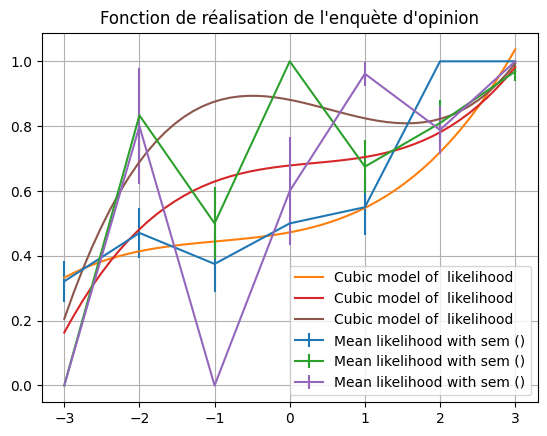

In [14]:
r0 = compute_meanfeedback_per_action(f0)
#mf1,ef1,model1 = compute_meanfeedback(f1)
for ac in ["weekly","monthly","as_usual"]:
    meandic,errdic,model = r0[ac]
    plotting(meandic,errdic,model)
#plotting(mf0,ef0,model0)
#plotting(mf1,ef1,model1)
plt.title("Fonction de réalisation de l'enquète d'opinion")
plt.legend()
plt.grid(visible=True)

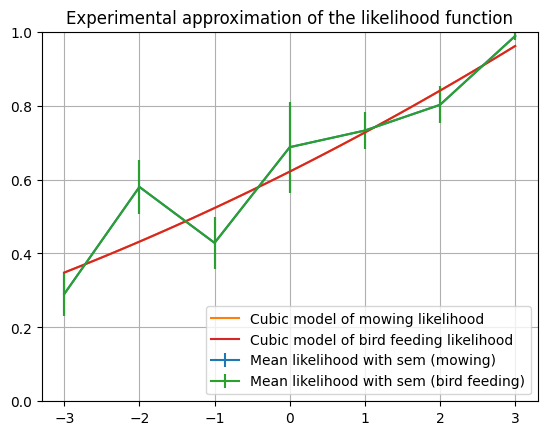

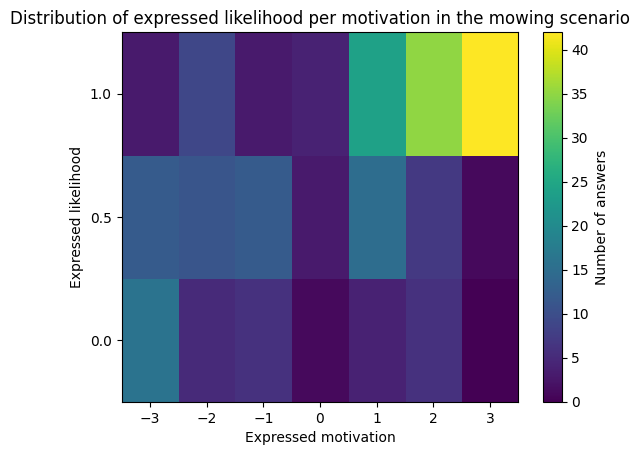

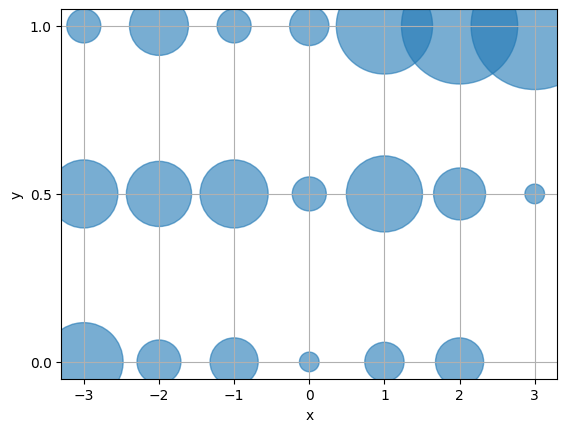

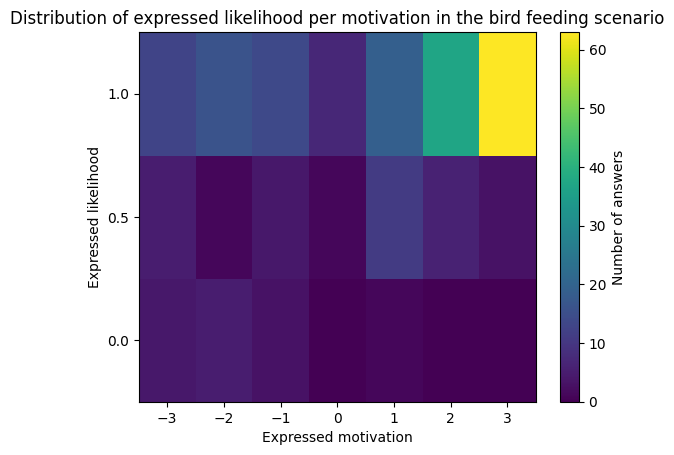

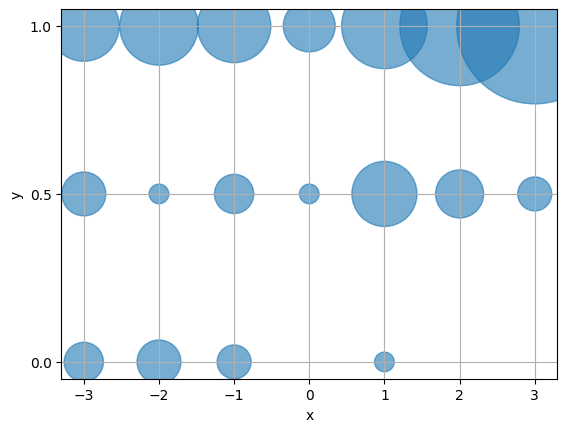

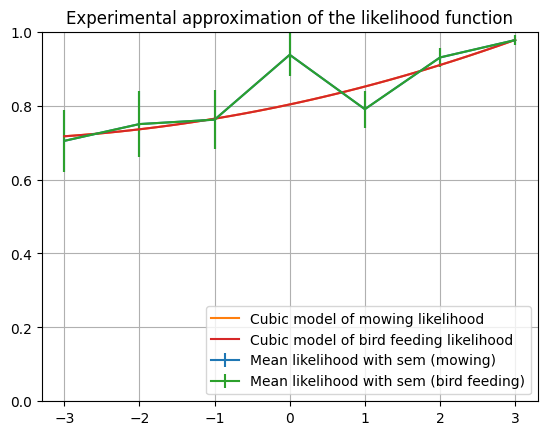

/tmp/ipykernel_7870/3279559728.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["nfeedback"] = df["feedback"].map(feedback_map)
/tmp/ipykernel_7870/3279559728.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["nfeedback"] = df["feedback"].map(feedback_map)
/home/nov/.local/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/nov/.local/lib/python3.10/site-packages/numpy/_core/_

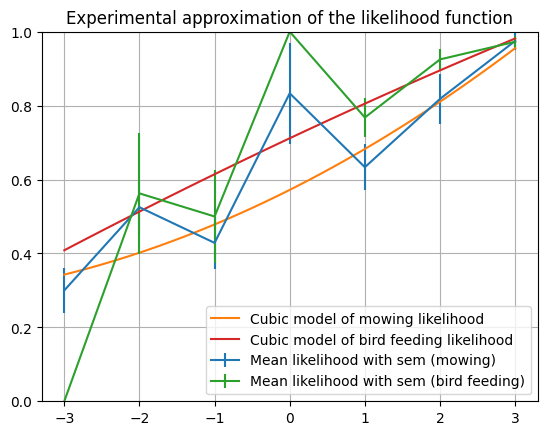

In [21]:
from collections import Counter
dots,meandic,errdic,model  = compute_meanfeedback(f0)


def plot_heatmap(dots,title):
    points = []

    x,y = [],[]

    for (motiv,likelihoods) in dots.items():
        for l in likelihoods:
            x.append(motiv)
            y.append(l)
            points.append((motiv,l))


    # Define grid
    x_vals = np.arange(-3, 4)          # -3 to 3
    y_vals = np.array([0, 0.5, 1])     # allowed y values

    # Count occurrences
    counts = Counter(points)

    # Build heatmap array
    heatmap = np.zeros((len(y_vals), len(x_vals)))

    for (x, y), c in counts.items():
        x_idx = np.where(x_vals == x)[0][0]
        y_idx = np.where(y_vals == y)[0][0]
        heatmap[y_idx, x_idx] = c

    # Plot
    plt.imshow(
        heatmap,
        origin="lower",
        cmap="viridis",
        extent=[-3.5, 3.5, -0.25, 1.25],
        aspect="auto"
    )

    plt.title(title)
    plt.colorbar(label="Number of answers")
    plt.xticks(x_vals)
    plt.yticks(y_vals)
    plt.xlabel("Expressed motivation")
    plt.ylabel("Expressed likelihood")

    plt.show()


    xs = [p[0] for p in counts]
    ys = [p[1] for p in counts]
    sizes = [counts[p] * 200 for p in counts]  # scale factor for visibility

    # Plot
    plt.scatter(xs, ys, s=sizes, alpha=0.6)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xticks(range(-3, 4))
    plt.yticks([0, 0.5, 1])
    plt.grid(True)

    plt.show()

plotting(meandic,errdic,model,"mowing")
plotting(meandic,errdic,model,"bird feeding")
plt.title("Experimental approximation of the likelihood function") 
plt.ylim((0,1))
plt.legend(loc="lower right")
plt.grid(visible=True)
plt.show()


plot_heatmap(dots,"Distribution of expressed likelihood per motivation in the mowing scenario")

dots,meandic,errdic,model  = compute_meanfeedback(f1)

plot_heatmap(dots,"Distribution of expressed likelihood per motivation in the bird feeding scenario")

plotting(meandic,errdic,model,"mowing")
plotting(meandic,errdic,model,"bird feeding")
plt.title("Experimental approximation of the likelihood function") 
plt.ylim((0,1))
plt.legend(loc="lower right")
plt.grid(visible=True)
plt.show()

g0 = f0[~f0["n"].isin([20,21,71,108])]
g1 = f1[~f1["n"].isin([12,13,19,25,27,68,76,77,105,107,118])]

g0 = f0[f0["action_name"]!="as_usual"]
g1 = f1[f1["action_name"]!="notatall"]


dots,meandic,errdic,model  = compute_meanfeedback(g0)

plotting(meandic,errdic,model,"mowing")
dots,meandic,errdic,model  = compute_meanfeedback(g1)

plotting(meandic,errdic,model,"bird feeding")
plt.title("Experimental approximation of the likelihood function") 
plt.ylim((0,1))
plt.legend(loc="lower right")
plt.grid(visible=True)


In [16]:
def compute_motiv_distrib(df,action_names):
    motiv_distrib = {ac:{-3:0,-2:0,-1:0,0:0,1:0,2:0,3:0}for ac in action_names}
    def update_distrib(row):
        motiv_distrib[row["action_name"]][row["motivation"]]+=1

    df.apply(update_distrib,axis=1) 
    coords = {ac:[[],[]] for ac in action_names}
    for ac in action_names:
        for (k,v) in motiv_distrib[ac].items():
            coords[ac][0].append(k)
            coords[ac][1].append(v)
    print(motiv_distrib)
    return coords,motiv_distrib

{'weekly': {-3: 32, -2: 18, -1: 13, 0: 1, 1: 11, 2: 2, 3: 4}, 'monthly': {-3: 3, -2: 3, -1: 12, 0: 2, 1: 21, 2: 24, 3: 16}, 'as_usual': {-3: 1, -2: 5, -1: 0, 0: 8, 1: 15, 2: 29, 3: 23}}
{'weekly': {-3: 0, -2: 4, -1: 5, 0: 1, 1: 14, 2: 20, 3: 30}, 'monthly': {-3: 0, -2: 5, -1: 3, 0: 2, 1: 15, 2: 23, 3: 26}, 'notatall': {-3: 22, -2: 15, -1: 13, 0: 7, 1: 3, 2: 3, 3: 11}}


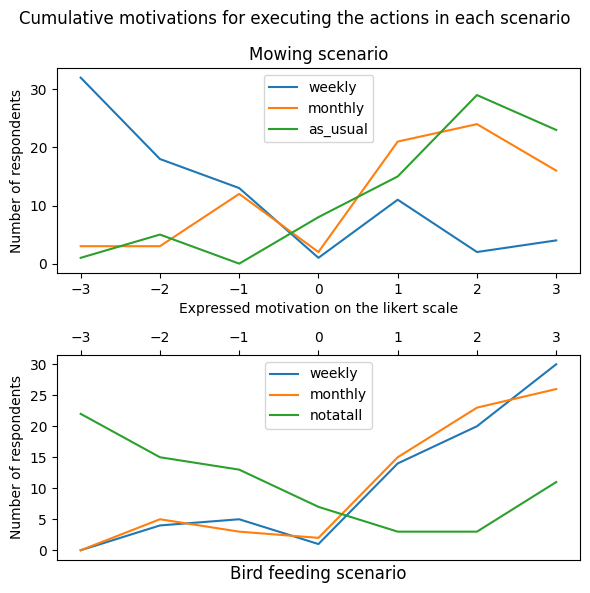

In [17]:
def plot_motiv(actions,coords,motiv_distrib,graph):
    for ac in actions:
        x,y = coords[ac]
        graph.plot(x,y,label = ac)
    model = np.polyfit(x,y,deg = 4)
    x = np.linspace(-3,3,50)
    y = [np.polyval(model, i) for i in x]
    graph.legend()

fig, (ax1, ax2) = plt.subplots(2,figsize=(6,6))
fig.suptitle('Cumulative motivations for executing the actions in each scenario')

actions = ["weekly","monthly","as_usual"]
coords,motiv_distrib = compute_motiv_distrib(m0,actions)
ax1.set_title("Mowing scenario")
plot_motiv(actions,coords,motiv_distrib,ax1)

actions = ["weekly","monthly","notatall"]
coords,motiv_distrib = compute_motiv_distrib(m1,actions)
ax2.set_title("Bird feeding scenario",y =0 , pad = -14)
ax1.set(xlabel="Expressed motivation on the likert scale")
ax2.xaxis.set_label_position('top')
plot_motiv(actions,coords,motiv_distrib,ax2)
ax1.set(ylabel="Number of respondents")

ax2.set(ylabel="Number of respondents")
ax2.xaxis.tick_top()
fig.tight_layout()


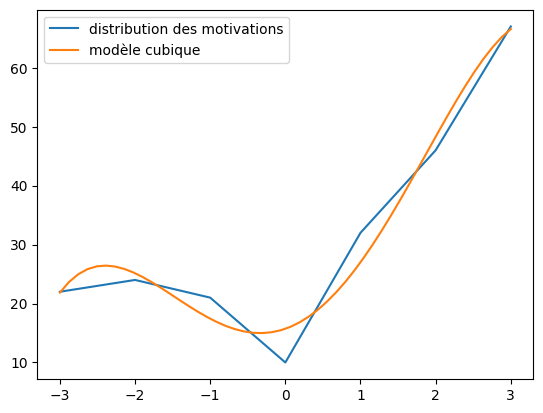

In [18]:
x,y = [],[]
combined_coords = {-3:0,-2:0,-1:0,0:0,1:0,2:0,3:0}
for ac in actions:
    for (k,v) in motiv_distrib[ac].items():
        combined_coords[k]+=v

for (k,v) in combined_coords.items():
    x.append(k)
    y.append(v) 

plt.plot(x,y,label = "distribution des motivations")
model = np.polyfit(x,y,deg = 4)
x = np.linspace(-3,3,50)
y = [np.polyval(model, i) for i in x]
plt.plot(x,y,label = "modèle cubique")
plt.legend()